# Dataset description
## Inbound Migration
**Source**: Migración Colombia

**Download**: [Datos Abiertos](https://www.datos.gov.co/Estad-sticas-Nacionales/Entradas-de-extranjeros-a-Colombia/96sh-4v8d/about_data)

# Code
## Imports

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [61]:
path = "./data/migration.csv"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,7])

## Clean data

In [62]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
june = df[df["Fecha"].dt.month == 6]
most_visited = june.groupby("País")["Total_out"].sum().nlargest(5)

countries = {
    "Estados Unidos De América": "United States of America",
    "España": "Spain",
    "México": "Mexico",
    "Panamá": "Panama",
    "Ecuador": "Ecuador"
}

most_visited.index = most_visited.index.map(countries).tolist()

most_visited = most_visited.sort_values()

## Plot

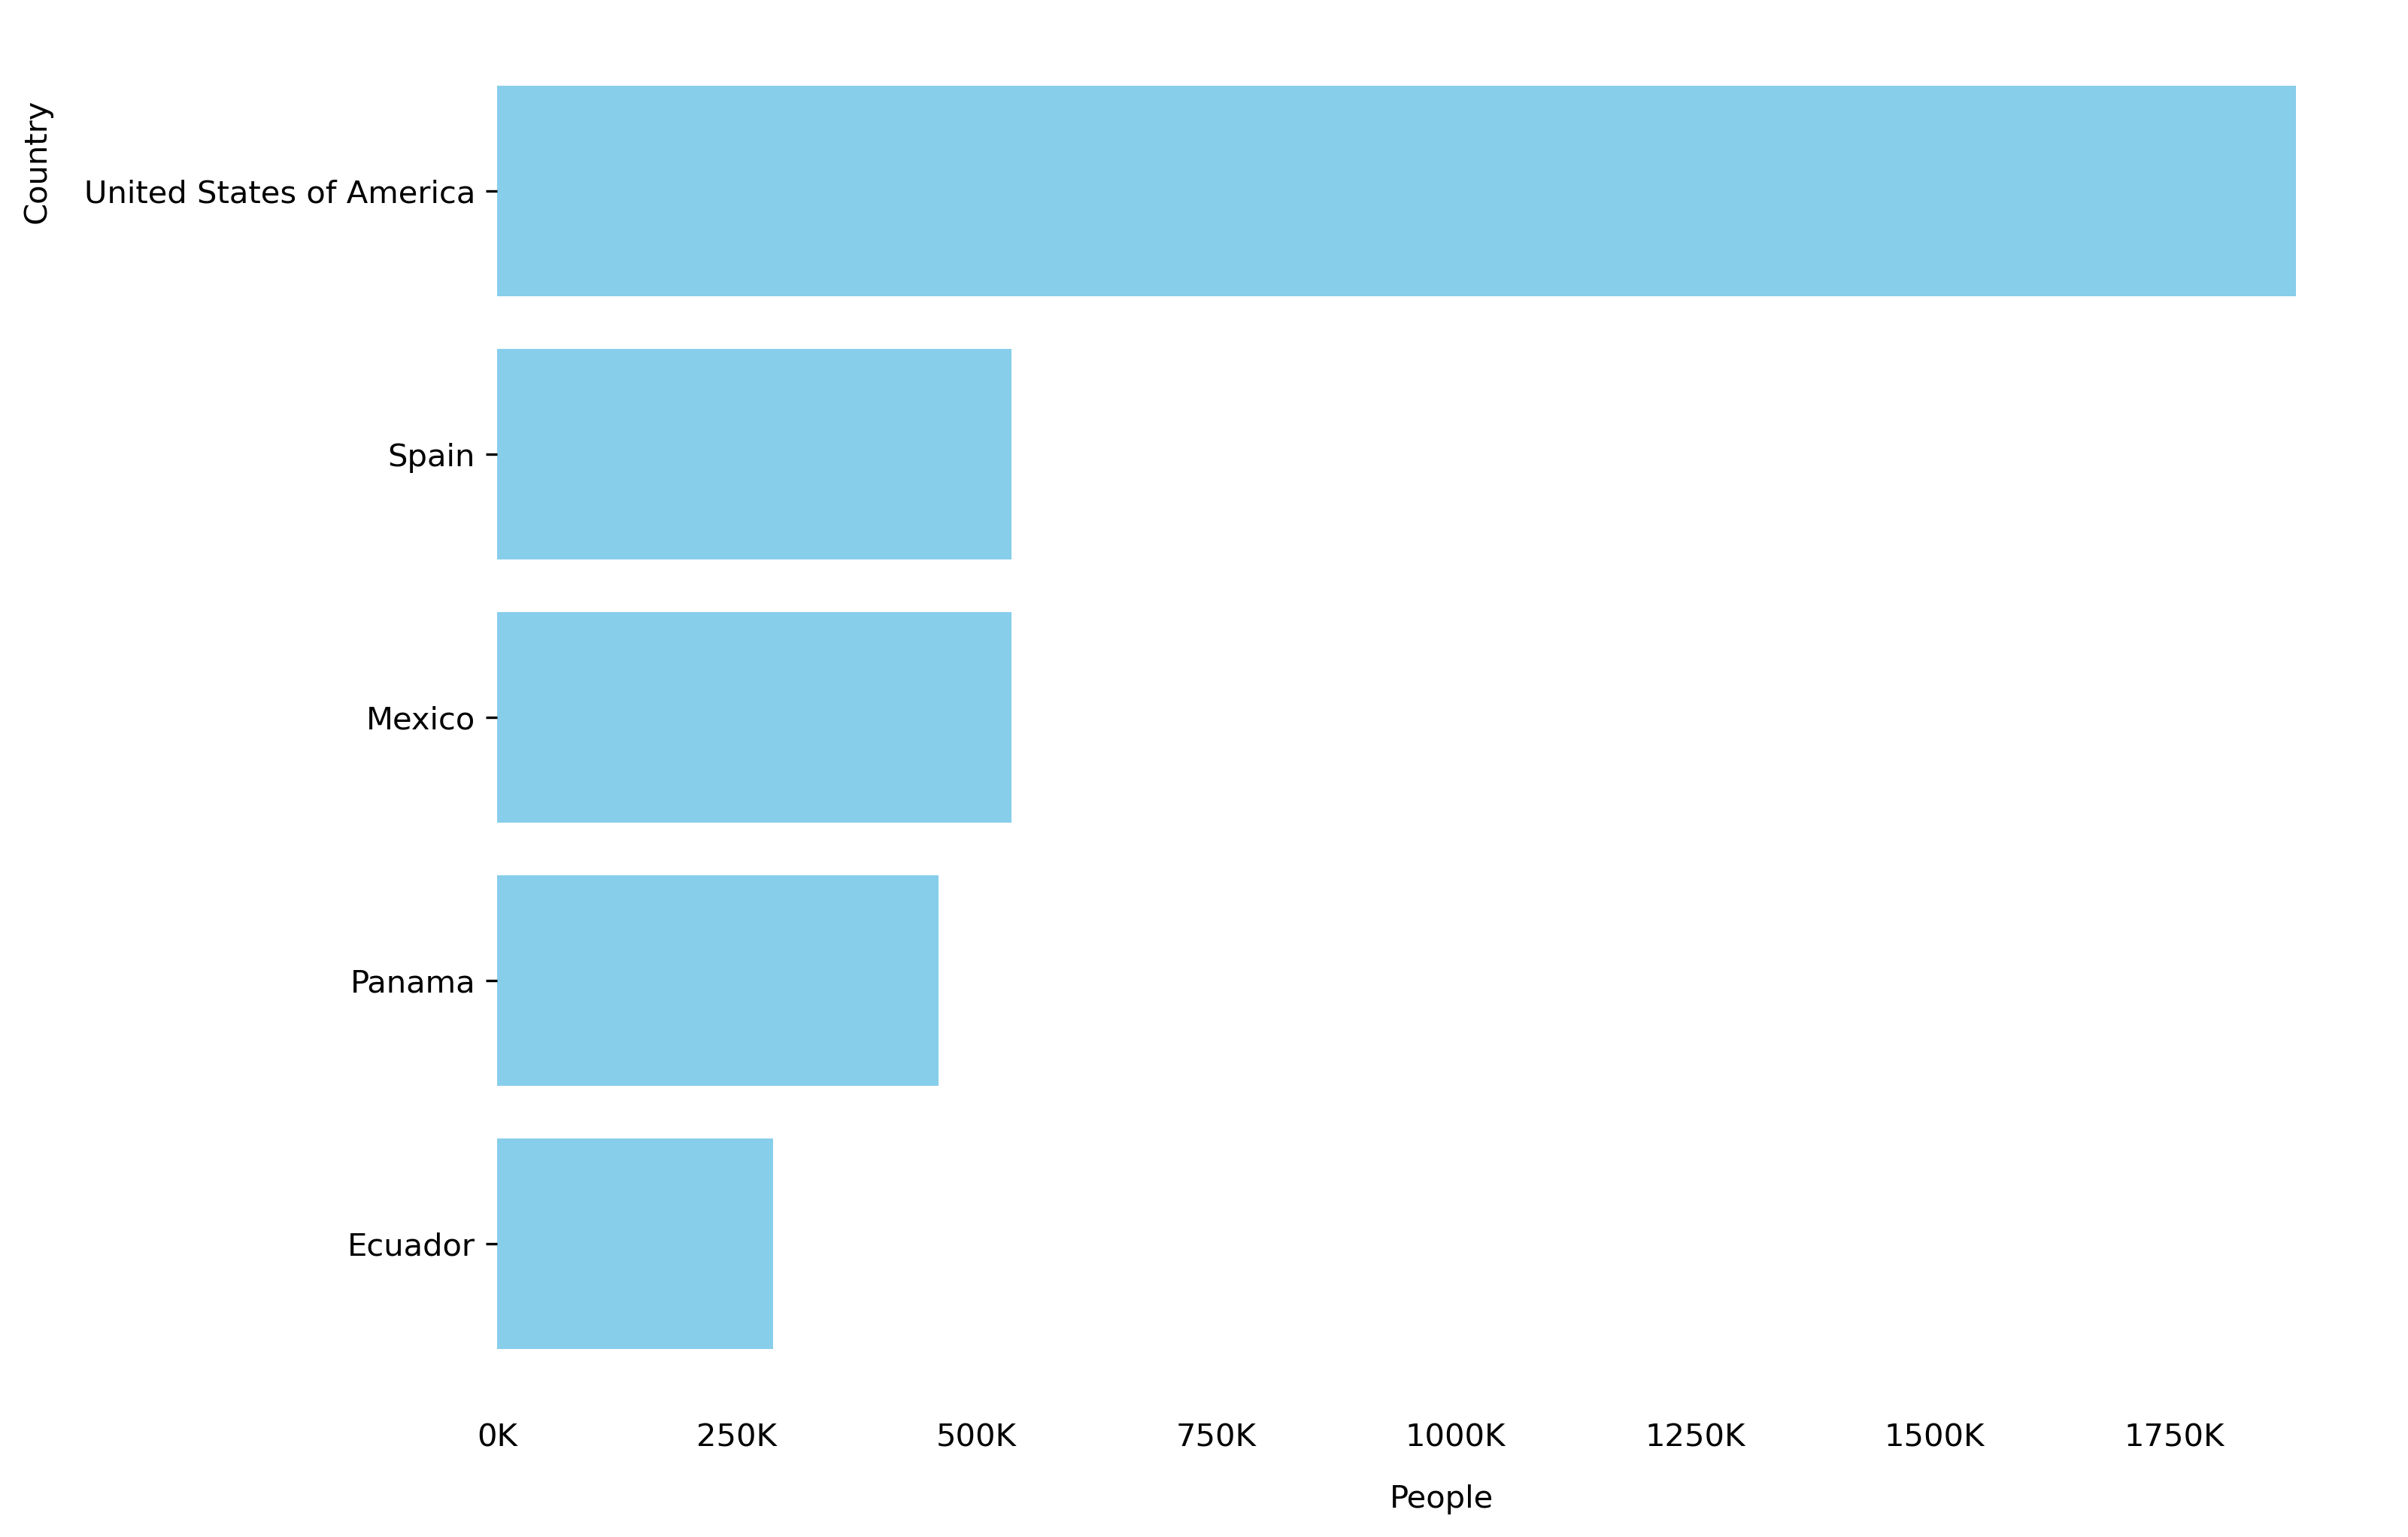

In [63]:
plt.figure(figsize=(10.8, 8), dpi=300)

plt.barh(most_visited.index, most_visited.values, color="skyblue")

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

for side in ["top", "left", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.ylabel("Country", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("People", labelpad=10, fontsize=10)

plt.tick_params(axis="x", length=0)

plt.show()